# 📡 TelecomX — Análisis de Evasión de Clientes (Churn)

## 🔹 Introducción

TelecomX es una empresa de telecomunicaciones que enfrenta un índice significativo de **evasión de clientes (Churn)**, lo que representa una pérdida directa de ingresos y un incremento en los costos de adquisición de nuevos clientes.

### Objetivo del análisis

El presente análisis tiene como propósito:

- Comprender el **perfil demográfico y de comportamiento** de los clientes que abandonan el servicio.
- Identificar las **variables con mayor correlación** con la evasión.
- Proporcionar **insights accionables** que permitan diseñar estrategias de retención efectivas.

### Dataset

| Atributo | Valor |
|---|---|
| **Fuente** | TelecomX_Data.json (GitHub) |
| **Registros** | 7,043 clientes |
| **Variables** | 20 atributos (demográficos, servicios y facturación) |
| **Variable objetivo** | `Evasor` — `True` si el cliente abandonó el servicio, `False` si permanece activo |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import json
import numpy as np
import seaborn as sns

## 🔹 Limpieza y Tratamiento de Datos

### 📥 Extracción de Datos

Los datos se obtienen directamente desde una fuente pública en formato **JSON** alojada en GitHub. Se utiliza la librería `requests` para la descarga y `pd.json_normalize()` para aplanar la estructura anidada del JSON en un DataFrame tabular de pandas.

In [2]:
import requests

url_telecom = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url_telecom)
telecom_json = response.json() # Esto nos da una lista de diccionarios o el JSON base

# Normalizamos el JSON pasándolo a un DataFrame de pandas
Telecom_normalizado = pd.json_normalize(telecom_json)

# Mostramos el dataframe
Telecom_normalizado


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [3]:
Telecom_normalizado['Churn'].unique()


array(['No', 'Yes', ''], dtype=object)

In [4]:
Telecom_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [5]:
Telecom_normalizado.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasor',
    'customer.gender': 'Género',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.Partner':'Con_Pareja',
    'customer.Dependents':'Con_Dependientes',
    'customer.tenure':'Meses_como_cliente',
    'phone.PhoneService':'Servicio_Telefonico',
    'phone.MultipleLines':'Multiples_Líneas_Telefonicas',
    'internet.InternetService':'Servicio_Internet',
    'internet.OnlineSecurity':'Seguridad_Online',
    'internet.OnlineBackup':'Copia_Seguridad_Online',
    'internet.DeviceProtection':'Protección_Dispositivos',
    'internet.TechSupport':'Soporte_Técnico',
    'internet.StreamingMovies':'Servicio_Streaming',
    'internet.StreamingTV':'Servicio_Streaming_TV',
    'account.Contract':'Tipo_Contrato',
    'account.PaymentMethod':'Método_Pago',
    'account.Charges.Monthly':'Cargos_Mensuales',
    'account.Charges.Total':'Cargos_Totales',
    'account.PaperlessBilling':'Facturación_Sin_Papel'
}, inplace=True)
Telecom_normalizado

,ID_Cliente,Evasor,Género,Adulto_Mayor,Con_Pareja,Con_Dependientes,Meses_como_cliente,Servicio_Telefonico,Multiples_Líneas_Telefonicas,Servicio_Internet,...,Copia_Seguridad_Online,Protección_Dispositivos,Soporte_Técnico,Servicio_Streaming_TV,Servicio_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


### 🔧 Transformación y Limpieza

Se realizan los siguientes pasos para garantizar la calidad e integridad del dataset:

1. **Renombrado de columnas** al español con nombres descriptivos y estandarizados.
2. **Tratamiento de la variable objetivo** (`Evasor`): conversión de `'Yes'/'No'` a booleanos (`True/False`) y eliminación de 11 registros sin valor.
3. **Conversión de tipos de datos**:
   - Variables con respuesta Sí/No → `boolean`
   - Variables nominales (`Género`, `Tipo_Contrato`, `Método_Pago`) → `category`
   - Variables numéricas (`Cargos_Mensuales`, `Cargos_Totales`) → `float` redondeado a 2 decimales
4. **Ordenamiento** del dataset por múltiples criterios para facilitar la inspección visual.

In [6]:
Telecom_normalizado[Telecom_normalizado['Evasor'] == '']
(Telecom_normalizado['Evasor'] == '').sum()


np.int64(224)

In [7]:
Telecom_normalizado['Evasor'] = Telecom_normalizado['Evasor'].replace({
    'Yes': True,
    'No': False,
    '': np.nan
}).astype('boolean')

Telecom_normalizado

,ID_Cliente,Evasor,Género,Adulto_Mayor,Con_Pareja,Con_Dependientes,Meses_como_cliente,Servicio_Telefonico,Multiples_Líneas_Telefonicas,Servicio_Internet,...,Copia_Seguridad_Online,Protección_Dispositivos,Soporte_Técnico,Servicio_Streaming_TV,Servicio_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,False,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,False,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,True,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,True,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,False,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [8]:
# Eliminar filas donde Evasor es NaN
Telecom_limpio = Telecom_normalizado.dropna(subset=['Evasor'])
    

In [9]:
Telecom_limpio['Evasor'].value_counts(normalize=True)


,proportion
Evasor,
False,0.73463
True,0.26537


In [10]:
Telecom_limpio.shape


(7043, 21)

In [11]:
Telecom_limpio.describe()

,Adulto_Mayor,Meses_como_cliente,Cargos_Mensuales
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
Telecom_limpio.value_counts('Evasor')

,count
Evasor,
False,5174
True,1869


In [13]:

Telecom_limpio = Telecom_limpio.copy()

# 2. Género
Telecom_limpio.loc[:, 'Género'] = (
    Telecom_limpio['Género']
    .replace({'Female': 'Mujer', 'Male': 'Hombre'})
    .astype('category')
)

# 4, 5, 7, 17. Booleanos básicos
cols_bool_basico = [
    'Con_Pareja',
    'Con_Dependientes',
    'Servicio_Telefonico',
    'Facturación_Sin_Papel'
]

for col in cols_bool_basico:
    Telecom_limpio.loc[:, col] = (
        Telecom_limpio[col]
        .map({'Yes': True, 'No': False})
        .astype('boolean')
    )

# 8. Múltiples líneas telefónicas
Telecom_limpio.loc[:, 'Multiples_Líneas_Telefonicas'] = (
    Telecom_limpio['Multiples_Líneas_Telefonicas']
    .map({'Yes': True, 'No': False, 'No phone service': False})
    .astype('boolean')
)

# 9. Servicio de Internet
Telecom_limpio.loc[:, 'Servicio_Internet'] = (
    Telecom_limpio['Servicio_Internet']
    .map({'DSL': True, 'Fiber optic': True, 'No': False})
    .astype('boolean')
)

# 10 al 15. Servicios dependientes de internet
cols_servicios_int = [
    'Seguridad_Online',
    'Copia_Seguridad_Online',
    'Protección_Dispositivos',
    'Soporte_Técnico',
    'Servicio_Streaming_TV',
    'Servicio_Streaming'
]

for col in cols_servicios_int:
    Telecom_limpio.loc[:, col] = (
        Telecom_limpio[col]
        .map({'Yes': True, 'No': False, 'No internet service': False})
        .astype('boolean')
    )

# 0. ID Cliente
Telecom_limpio.loc[:, 'ID_Cliente'] = Telecom_limpio['ID_Cliente'].astype('string')

# 16. Tipo de contrato
Telecom_limpio.loc[:, 'Tipo_Contrato'] = Telecom_limpio['Tipo_Contrato'].astype('category')

# 18. Método de pago
Telecom_limpio.loc[:, 'Método_Pago'] = Telecom_limpio['Método_Pago'].astype('category')

# 19. Cargos mensuales
Telecom_limpio.loc[:, 'Cargos_Mensuales'] = (Telecom_limpio['Cargos_Mensuales'].astype(float).round(2))

# 20. Cargos totales
Telecom_limpio.loc[:, 'Cargos_Totales'] = (
    pd.to_numeric(Telecom_limpio['Cargos_Totales'], errors='coerce')
    .round(2)
)

# Verificación final
Telecom_limpio.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_Cliente                    7043 non-null   object 
 1   Evasor                        7043 non-null   boolean
 2   Género                        7043 non-null   object 
 3   Adulto_Mayor                  7043 non-null   int64  
 4   Con_Pareja                    7043 non-null   object 
 5   Con_Dependientes              7043 non-null   object 
 6   Meses_como_cliente            7043 non-null   int64  
 7   Servicio_Telefonico           7043 non-null   object 
 8   Multiples_Líneas_Telefonicas  7043 non-null   object 
 9   Servicio_Internet             7043 non-null   object 
 10  Seguridad_Online              7043 non-null   object 
 11  Copia_Seguridad_Online        7043 non-null   object 
 12  Protección_Dispositivos       7043 non-null   object 
 13  Soporte_

In [14]:
Telecom_limpio = Telecom_limpio.sort_values(by=['Evasor', 'Con_Pareja', 'Con_Dependientes', 'Meses_como_cliente', 'Servicio_Internet', 'Servicio_Streaming', 'Meses_como_cliente', 'Cargos_Totales', 'Cargos_Mensuales', 'Seguridad_Online' ,'Protección_Dispositivos', 'Tipo_Contrato'], ascending=False)


In [15]:
Telecom_limpio.describe()

,Adulto_Mayor,Meses_como_cliente,Cargos_Mensuales
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
Telecom_limpio

,ID_Cliente,Evasor,Género,Adulto_Mayor,Con_Pareja,Con_Dependientes,Meses_como_cliente,Servicio_Telefonico,Multiples_Líneas_Telefonicas,Servicio_Internet,...,Copia_Seguridad_Online,Protección_Dispositivos,Soporte_Técnico,Servicio_Streaming_TV,Servicio_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargos_Mensuales,Cargos_Totales
6416,8809-RIHDD,True,Hombre,0,True,True,72,True,True,True,...,True,True,False,True,True,Two year,True,Electronic check,103.40,7372.65
6236,8580-QVLOC,True,Mujer,1,True,True,72,True,True,True,...,True,True,True,True,True,Two year,False,Credit card (automatic),92.45,6440.25
2340,3259-FDWOY,True,Hombre,0,True,True,71,True,True,True,...,True,True,False,True,True,Two year,True,Bank transfer (automatic),106.00,7723.7
3860,5287-QWLKY,True,Hombre,1,True,True,71,True,True,True,...,True,False,False,True,True,Month-to-month,True,Credit card (automatic),105.10,7548.1
1099,1555-DJEQW,True,Mujer,0,True,True,70,True,True,True,...,True,True,True,True,True,Two year,True,Bank transfer (automatic),114.20,7723.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,6569-KTMDU,False,Mujer,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.10,19.1
6842,9441-QHEVC,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.10,19.1
707,1015-OWJKI,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.05,19.05
7257,9975-SKRNR,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,18.90,18.9


In [17]:
# Asegurar que Telecom_limpio no se modifica
Telecom_limpio = Telecom_limpio.copy()

# Separación por variable objetivo
df_evasores = Telecom_limpio.loc[Telecom_limpio['Evasor'] == True].copy()
df_no_evasores = Telecom_limpio.loc[Telecom_limpio['Evasor'] == False].copy()
df_evasores

,ID_Cliente,Evasor,Género,Adulto_Mayor,Con_Pareja,Con_Dependientes,Meses_como_cliente,Servicio_Telefonico,Multiples_Líneas_Telefonicas,Servicio_Internet,...,Copia_Seguridad_Online,Protección_Dispositivos,Soporte_Técnico,Servicio_Streaming_TV,Servicio_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargos_Mensuales,Cargos_Totales
6416,8809-RIHDD,True,Hombre,0,True,True,72,True,True,True,...,True,True,False,True,True,Two year,True,Electronic check,103.40,7372.65
6236,8580-QVLOC,True,Mujer,1,True,True,72,True,True,True,...,True,True,True,True,True,Two year,False,Credit card (automatic),92.45,6440.25
2340,3259-FDWOY,True,Hombre,0,True,True,71,True,True,True,...,True,True,False,True,True,Two year,True,Bank transfer (automatic),106.00,7723.7
3860,5287-QWLKY,True,Hombre,1,True,True,71,True,True,True,...,True,False,False,True,True,Month-to-month,True,Credit card (automatic),105.10,7548.1
1099,1555-DJEQW,True,Mujer,0,True,True,70,True,True,True,...,True,True,True,True,True,Two year,True,Bank transfer (automatic),114.20,7723.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4201,5766-ZJYBB,True,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.40,19.4
538,0761-AETCS,True,Mujer,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Electronic check,19.30,19.3
3357,4667-OHGKG,True,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,True,Mailed check,19.30,19.3
4463,6121-VZNQB,True,Mujer,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,True,Mailed check,19.10,19.1


In [18]:
df_no_evasores

,ID_Cliente,Evasor,Género,Adulto_Mayor,Con_Pareja,Con_Dependientes,Meses_como_cliente,Servicio_Telefonico,Multiples_Líneas_Telefonicas,Servicio_Internet,...,Copia_Seguridad_Online,Protección_Dispositivos,Soporte_Técnico,Servicio_Streaming_TV,Servicio_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargos_Mensuales,Cargos_Totales
5523,7569-NMZYQ,False,Mujer,0,True,True,72,True,True,True,...,True,True,True,True,True,Two year,True,Bank transfer (automatic),118.75,8672.45
7072,9739-JLPQJ,False,Mujer,0,True,True,72,True,True,True,...,True,True,True,True,True,Two year,False,Credit card (automatic),117.50,8670.1
477,0675-NCDYU,False,Mujer,0,True,True,72,True,True,True,...,True,True,True,True,True,Two year,True,Credit card (automatic),116.40,8543.25
1062,1488-PBLJN,False,Mujer,0,True,True,72,True,True,True,...,True,True,True,True,True,Two year,True,Bank transfer (automatic),116.85,8477.7
4385,6007-TCTST,False,Mujer,0,True,True,72,True,True,True,...,True,True,True,True,True,Two year,True,Bank transfer (automatic),115.80,8476.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,6569-KTMDU,False,Mujer,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.10,19.1
6842,9441-QHEVC,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.10,19.1
707,1015-OWJKI,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,19.05,19.05
7257,9975-SKRNR,False,Hombre,0,False,False,1,True,False,False,...,False,False,False,False,False,Month-to-month,False,Mailed check,18.90,18.9


## 🔹 Análisis Exploratorio de Datos (EDA)

Se analizan las relaciones entre las variables del dataset y la variable objetivo `Evasor` mediante tres tipos de visualizaciones:

- **Variables categóricas** (`Género`, `Con_Pareja`, `Con_Dependientes`, `Tipo_Contrato`, `Método_Pago`): gráficas de conteo agrupadas por evasor para detectar diferencias entre grupos.
- **Servicios contratados** (variables booleanas): proporción de adopción de cada servicio comparando clientes evasores vs. no evasores.
- **Variables numéricas** (`Cargos_Mensuales`, `Cargos_Totales`, `Meses_como_cliente`, `Numero_Servicios`): distribuciones mediante boxplots para identificar diferencias en la dispersión y la mediana.

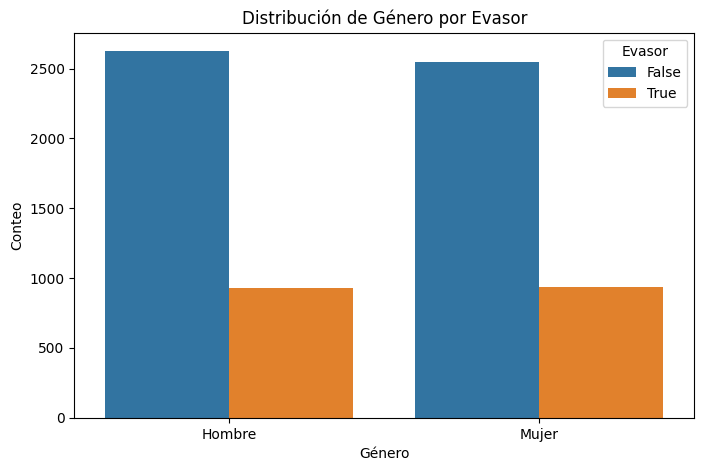

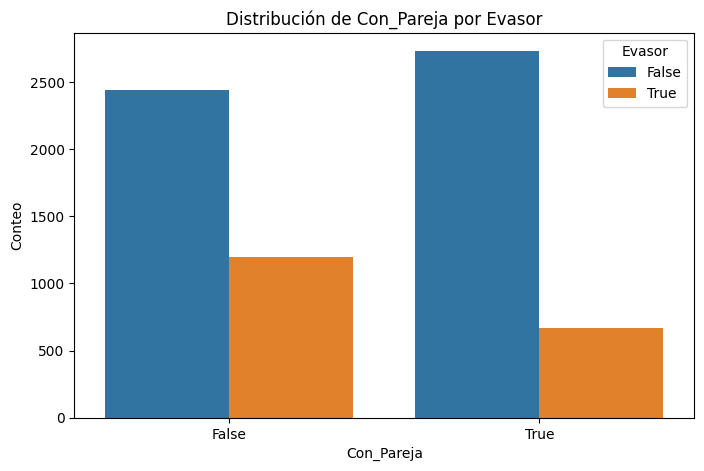

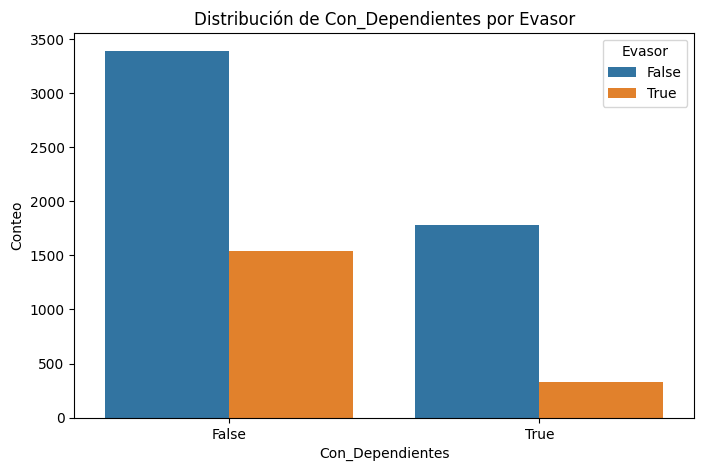

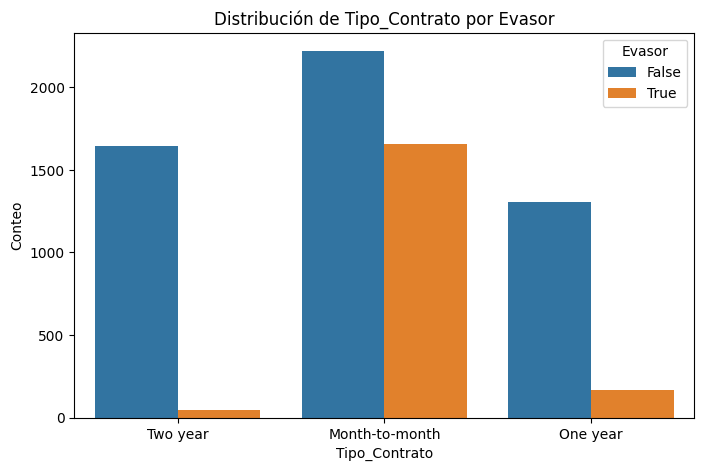

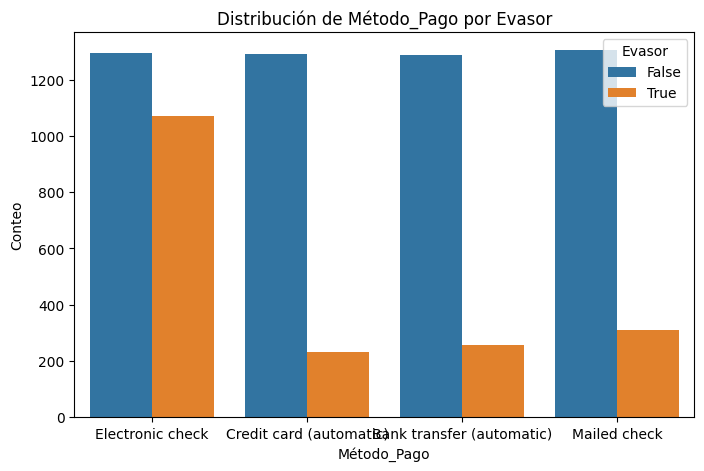

In [19]:
def plot_categorica(col):
    plt.figure(figsize=(8,5))
    sns.countplot(data=Telecom_limpio, x=col, hue='Evasor')
    plt.title(f'Distribución de {col} por Evasor')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.show()

plot_categorica('Género')
plot_categorica('Con_Pareja')
plot_categorica('Con_Dependientes')
plot_categorica('Tipo_Contrato')
plot_categorica('Método_Pago')


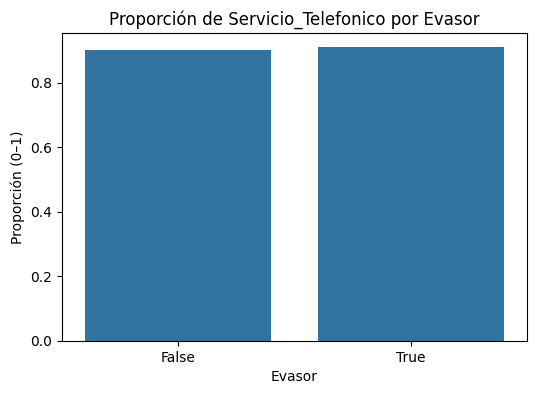

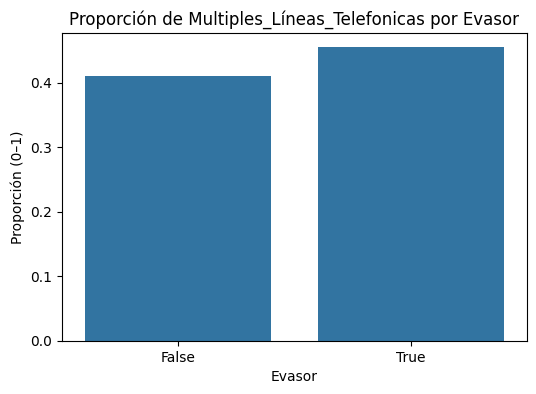

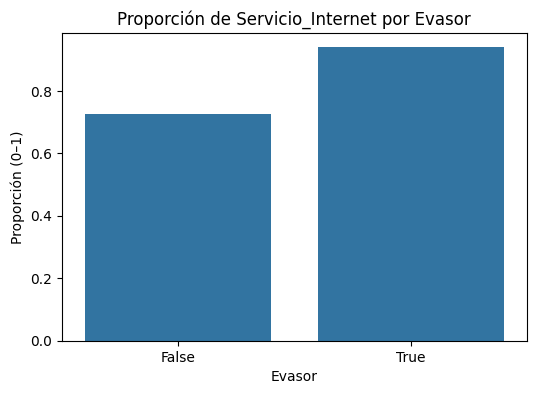

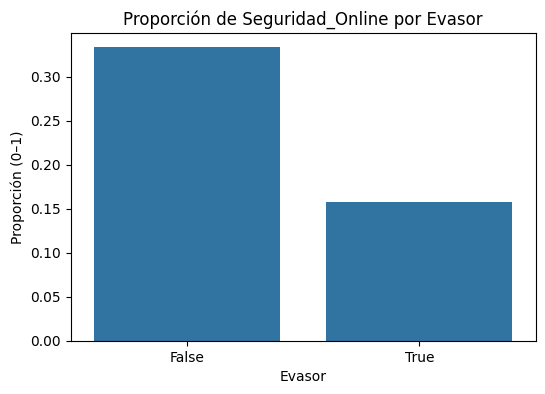

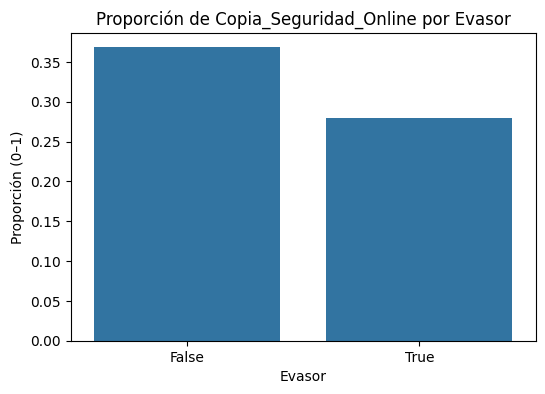

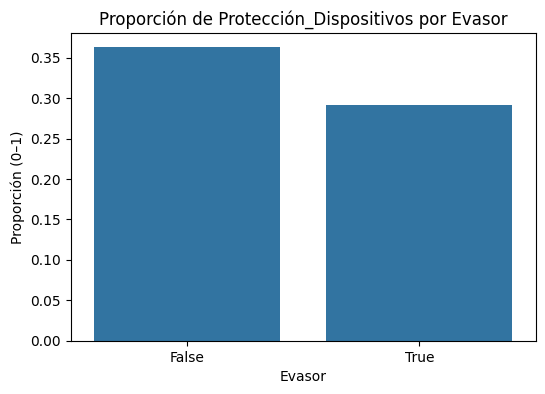

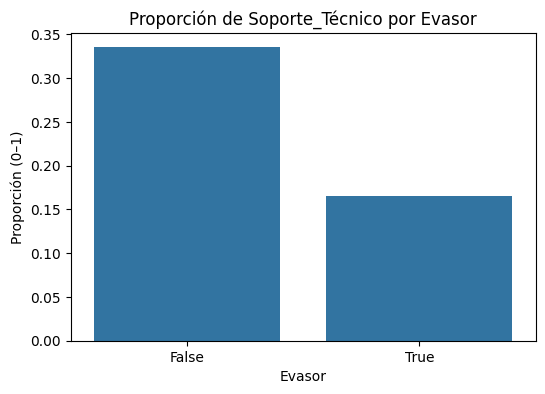

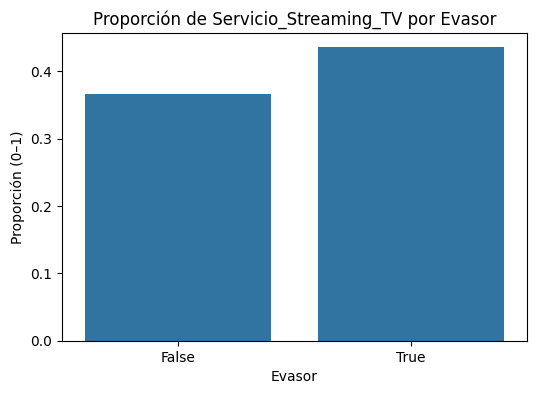

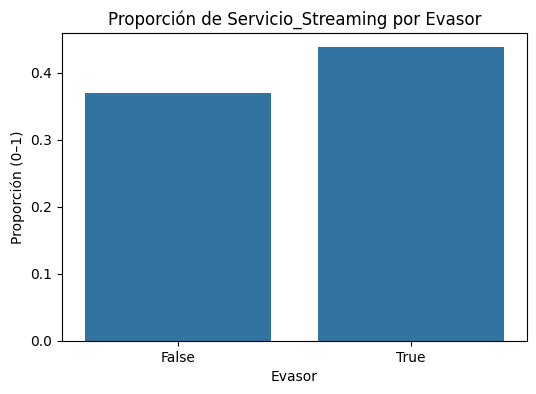

In [20]:
def plot_boolean(col):
    plt.figure(figsize=(6,4))
    prop = Telecom_limpio.groupby('Evasor')[col].mean()
    sns.barplot(x=prop.index, y=prop.values)
    plt.title(f'Proporción de {col} por Evasor')
    plt.ylabel('Proporción (0–1)')
    plt.show()

servicios = [
    'Servicio_Telefonico','Multiples_Líneas_Telefonicas','Servicio_Internet',
    'Seguridad_Online','Copia_Seguridad_Online','Protección_Dispositivos',
    'Soporte_Técnico','Servicio_Streaming_TV','Servicio_Streaming'
]

for s in servicios:
    plot_boolean(s)


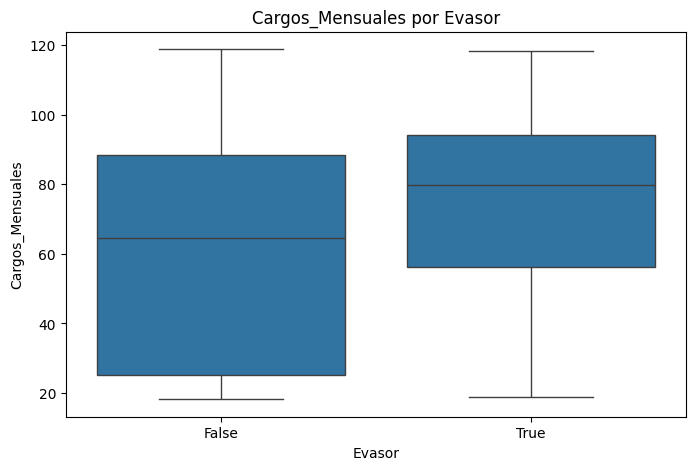

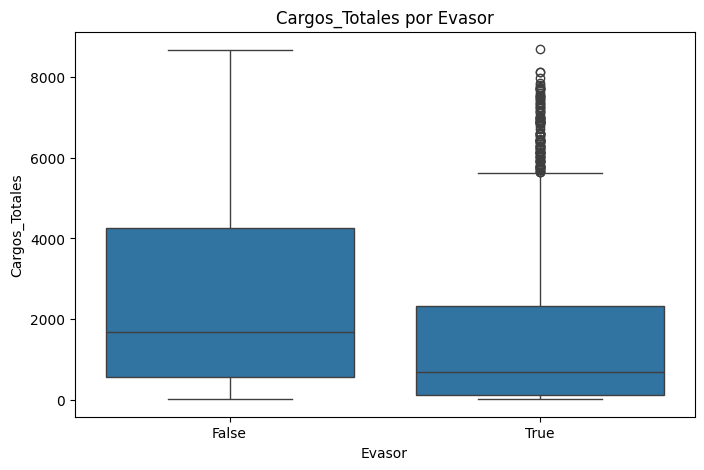

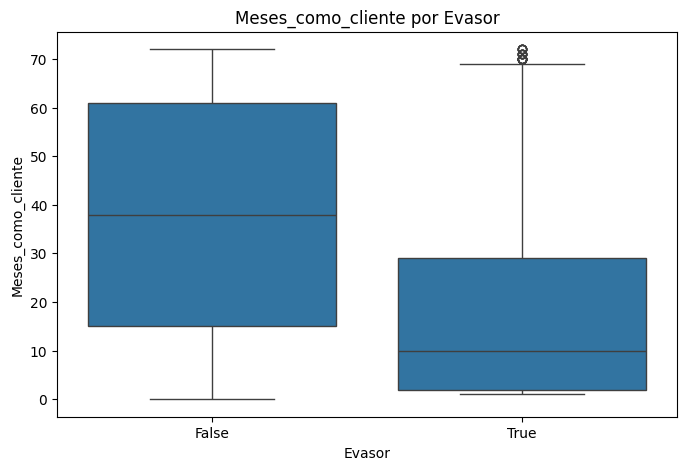

In [21]:
def plot_numerica(col):
    plt.figure(figsize=(8,5))
    sns.boxplot(data=Telecom_limpio, x='Evasor', y=col)
    plt.title(f'{col} por Evasor')
    plt.show()

plot_numerica('Cargos_Mensuales')
plot_numerica('Cargos_Totales')
plot_numerica('Meses_como_cliente')


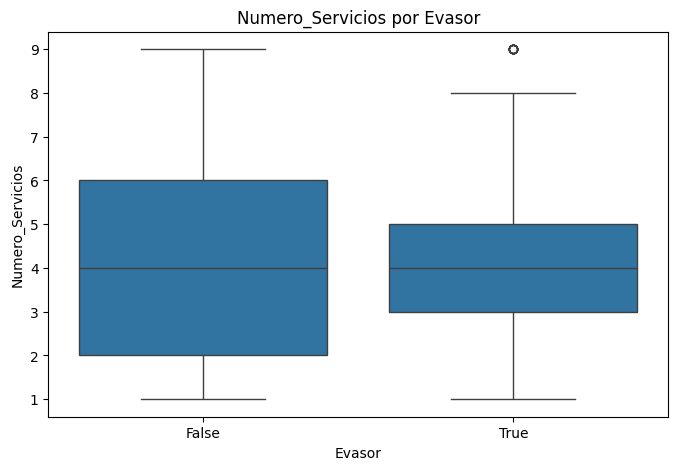

In [22]:
Telecom_limpio['Numero_Servicios'] = Telecom_limpio[
    servicios
].sum(axis=1)
plot_numerica('Numero_Servicios')

In [24]:

# Estadísticas para evaluar las gráficas
print("=== DISTRIBUCIÓN POR GÉNERO ===")
print(f"Tasa evasión Hombre: {Telecom_limpio[Telecom_limpio['Género']=='Hombre']['Evasor'].mean():.1%}")
print(f"Tasa evasión Mujer:  {Telecom_limpio[Telecom_limpio['Género']=='Mujer']['Evasor'].mean():.1%}")

print("\n=== CON_PAREJA ===")
print(f"Con Pareja=True:  {Telecom_limpio[Telecom_limpio['Con_Pareja']==True]['Evasor'].mean():.1%}")
print(f"Con Pareja=False: {Telecom_limpio[Telecom_limpio['Con_Pareja']==False]['Evasor'].mean():.1%}")

print("\n=== CON_DEPENDIENTES ===")
print(f"Con Dependientes=True:  {Telecom_limpio[Telecom_limpio['Con_Dependientes']==True]['Evasor'].mean():.1%}")
print(f"Con Dependientes=False: {Telecom_limpio[Telecom_limpio['Con_Dependientes']==False]['Evasor'].mean():.1%}")

print("\n=== TIPO_CONTRATO ===")
for c in Telecom_limpio['Tipo_Contrato'].unique():
    tasa = Telecom_limpio[Telecom_limpio['Tipo_Contrato']==c]['Evasor'].mean()
    print(f"  {c}: {tasa:.1%}")

print("\n=== MÉTODO_PAGO ===")
for m in Telecom_limpio['Método_Pago'].unique():
    tasa = Telecom_limpio[Telecom_limpio['Método_Pago']==m]['Evasor'].mean()
    print(f"  {m}: {tasa:.1%}")

print("\n=== SERVICIOS BOOLEANOS (Proporción con el servicio, por grupo Evasor) ===")
servicios = [
    'Servicio_Telefonico','Multiples_Líneas_Telefonicas','Servicio_Internet',
    'Seguridad_Online','Copia_Seguridad_Online','Protección_Dispositivos',
    'Soporte_Técnico','Servicio_Streaming_TV','Servicio_Streaming'
]
prop = Telecom_limpio.groupby('Evasor')[servicios].mean()
print(prop.T.rename(columns={False: 'No Evasor', True: 'Evasor'}).to_string())

print("\n=== VARIABLES NUMÉRICAS (media por grupo Evasor) ===")
for col in ['Cargos_Mensuales', 'Cargos_Totales', 'Meses_como_cliente']:
    m_eva = Telecom_limpio[Telecom_limpio['Evasor']==True][col].mean()
    m_no  = Telecom_limpio[Telecom_limpio['Evasor']==False][col].mean()
    print(f"  {col}: Evasor={m_eva:.1f}  No Evasor={m_no:.1f}")

print("\n=== NÚMERO DE SERVICIOS (media por grupo Evasor) ===")
m_eva = Telecom_limpio[Telecom_limpio['Evasor']==True]['Numero_Servicios'].mean()
m_no  = Telecom_limpio[Telecom_limpio['Evasor']==False]['Numero_Servicios'].mean()
print(f"  Evasor={m_eva:.2f}  No Evasor={m_no:.2f}")


=== DISTRIBUCIÓN POR GÉNERO ===
Tasa evasión Hombre: 26.2%
Tasa evasión Mujer:  26.9%

=== CON_PAREJA ===
Con Pareja=True:  19.7%
Con Pareja=False: 33.0%

=== CON_DEPENDIENTES ===
Con Dependientes=True:  15.5%
Con Dependientes=False: 31.3%

=== TIPO_CONTRATO ===
  Two year: 2.8%
  Month-to-month: 42.7%
  One year: 11.3%

=== MÉTODO_PAGO ===
  Electronic check: 45.3%
  Credit card (automatic): 15.2%
  Bank transfer (automatic): 16.7%
  Mailed check: 19.1%

=== SERVICIOS BOOLEANOS (Proporción con el servicio, por grupo Evasor) ===
Evasor                       No Evasor    Evasor
Servicio_Telefonico           0.901044  0.909042
Multiples_Líneas_Telefonicas  0.409934  0.454789
Servicio_Internet             0.726904   0.93954
Seguridad_Online              0.333204  0.157838
Copia_Seguridad_Online         0.36838  0.279829
Protección_Dispositivos       0.362775    0.2916
Soporte_Técnico               0.335137  0.165864
Servicio_Streaming_TV         0.365868  0.435527
Servicio_Streaming      

## 🔹 Conclusiones e Insights

El análisis exploratorio revela los factores con mayor impacto en la evasión de clientes:

| Variable | Observación Clave |
|---|---|
| **Tipo_Contrato** | Mes a mes → **42.7%** de evasión · Contrato bianual → solo **2.8%** |
| **Meses_como_cliente** | Evasores: promedio **18 meses** vs. **37.6** meses de no evasores |
| **Método_Pago** | Cheque electrónico → **45.3%** de evasión vs. 15–19% en métodos automáticos |
| **Soporte_Técnico** | Solo **16.6%** de evasores lo utiliza vs. **33.5%** de no evasores |
| **Seguridad_Online** | Solo **15.8%** de evasores la tiene vs. **33.3%** de no evasores |
| **Con_Dependientes** | Sin dependientes → **31.3%** · Con dependientes → **15.5%** |
| **Cargos_Mensuales** | Evasores pagan en promedio **$74.4/mes** vs. **$61.3** de no evasores |

### Variables sin impacto relevante

- **Género**: diferencia menor al 1% (Hombre 26.2% vs. Mujer 26.9%) — no es un predictor útil.
- **Número de Servicios**: diferencia mínima (4.07 vs. 4.17) — importa el *tipo* de servicio contratado, no la cantidad.

## 🔹 Recomendaciones Estratégicas

Con base en los hallazgos del análisis, se proponen las siguientes acciones para reducir la evasión:

1. **Incentivar contratos de largo plazo**: Ofrecer descuentos o beneficios exclusivos para migrar de contratos mes a mes a contratos anuales o bianuales. Los contratos bianuales presentan una tasa de evasión **15 veces menor** que los mensuales.

2. **Programa intensivo para clientes nuevos**: Diseñar un plan de acompañamiento personalizado durante los primeros **12–18 meses**, período donde el riesgo de abandono es significativamente más alto.

3. **Revisar la experiencia del cheque electrónico**: Investigar posibles fricciones en este método de pago e incentivar la migración a débito automático o tarjeta de crédito, que presentan tasas de evasión entre 16% y 19%.

4. **Promover Soporte Técnico y Seguridad Online como anclas de retención**: Estos servicios están presentes en más del doble de los clientes retenidos en comparación con los evasores. Se recomienda ofrecerlos en paquetes combinados o con períodos de prueba gratuitos.

5. **Atención diferenciada a clientes con cargos mensuales altos**: Clientes con facturas ≥ $74/mes tienen mayor propensión a abandonar. Propuestas de valor personalizadas o beneficios adicionales pueden compensar la percepción de costo alto.

6. **Focalizar retención en solteros y clientes sin dependientes**: Este segmento presenta tasas de evasión del 33% (sin pareja) y 31% (sin dependientes). Los programas de fidelización deben adaptarse a perfiles sin vínculos familiares establecidos.